# 🏥 Liver Disease AI Predictor
### 🚀 **Live Deployment**

Click the badge below to run the diagnostic dashboard:

[![Streamlit App](https://static.streamlit.io/badges/streamlit_badge_black_white.svg)](https://liver-disease-predictor-app-flspwmy3igbjywmzwwxnm4.streamlit.app/)

---
**Project Description:**
This project utilizes an XGBoost Classifier to predict liver disease based on clinical biomarkers. The live application provides a professional interface for doctors and patients to visualize risk factors and probability scores.

#### **Importing Libraries**

In [429]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **Loading Dataset**

In [430]:
# NOTE:
# Here the dataset uses semicolon (;) as the separator(delimiter)
df = pd.read_csv("Dataset-620.csv",sep=';')

In [431]:
# Display the first 5 rows of the dataset
df.head()

,category,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase,protein
0,no_disease,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69
1,no_disease,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,no_disease,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,no_disease,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,no_disease,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [432]:
df.shape

(615, 13)

In [433]:
# Shows exact column names, including hidden spaces
df.columns.tolist()

['category',
 'age',
 'sex',
 'albumin',
 'alkaline_phosphatase',
 'alanine_aminotransferase',
 'aspartate_aminotransferase',
 'bilirubin',
 'cholinesterase',
 'cholesterol',
 'creatinina',
 'gamma_glutamyl_transferase ',
 'protein   ']

In [434]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   category                     615 non-null    object 
 1   age                          615 non-null    int64  
 2   sex                          615 non-null    object 
 3   albumin                      614 non-null    float64
 4   alkaline_phosphatase         597 non-null    float64
 5   alanine_aminotransferase     614 non-null    float64
 6   aspartate_aminotransferase   615 non-null    float64
 7   bilirubin                    615 non-null    float64
 8   cholinesterase               615 non-null    float64
 9   cholesterol                  605 non-null    float64
 10  creatinina                   615 non-null    float64
 11  gamma_glutamyl_transferase   615 non-null    float64
 12  protein                      615 non-null    object 
dtypes: float64(9), int64

In [435]:
# Statistical summary
df.describe()

,age,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase
count,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000
mean,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171
std,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071
min,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000
25%,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000
50%,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000
75%,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000
max,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000


### **Checks the presence of "Target Imbalance"** 

category
 no_disease        533
 cirrhosis          30
 hepatitis          24
 fibrosis           21
suspect_disease      7
Name: count, dtype: int64


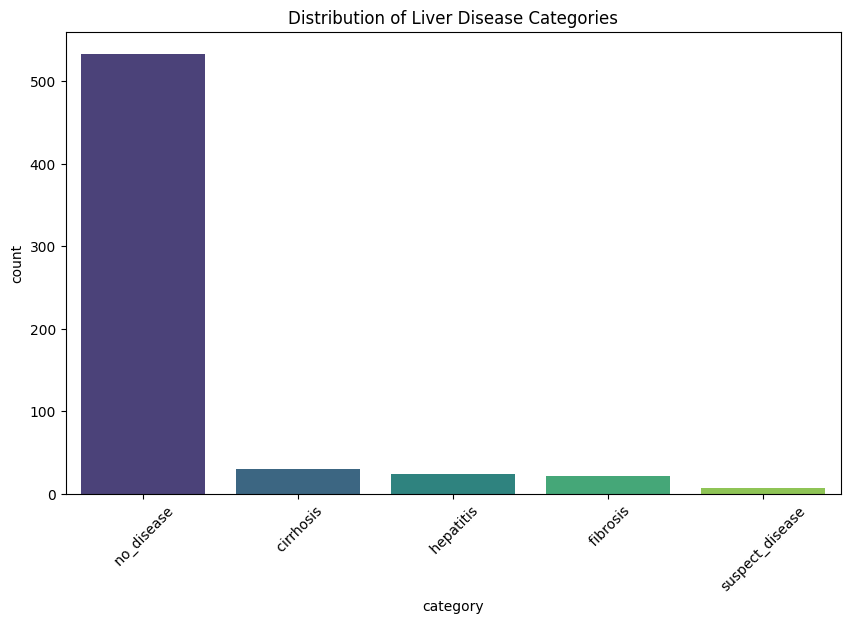

In [436]:
# Check and visualize the distribution of the target variable
print(df['category'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', palette='viridis', order=df['category'].value_counts().index)
plt.title('Distribution of Liver Disease Categories')
plt.xticks(rotation=45)
plt.show()

 ##### *By observing the result we can see there is "imbalance"*

### **Feature-Level Distribution Analysis**

#### **Gender Distribution**

sex
m    377
f    238
Name: count, dtype: int64


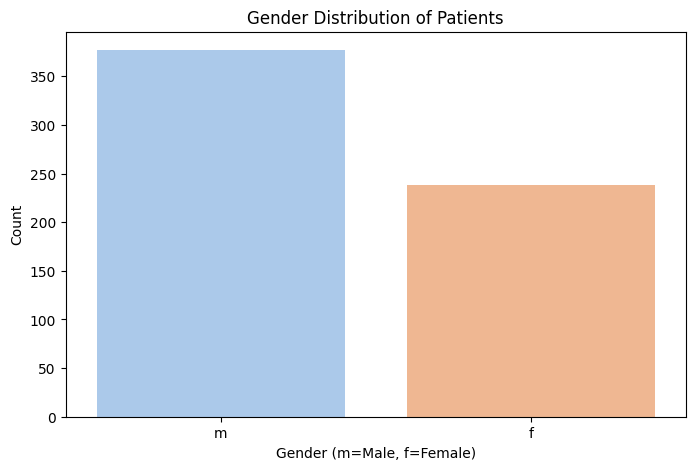

In [437]:
# Check and visualize gender distribution in the dataset
print(df['sex'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='pastel')
plt.title('Gender Distribution of Patients')
plt.xlabel('Gender (m=Male, f=Female)')
plt.ylabel('Count')
plt.show()

#### **Age Distribution**

In [438]:
# Summary statistics of age feature
df['age'].describe()

count    615.000000
mean      47.408130
std       10.055105
min       19.000000
25%       39.000000
50%       47.000000
75%       54.000000
max       77.000000
Name: age, dtype: float64

In [439]:
# Check missing values in each column
df.isnull().sum()

category                        0
age                             0
sex                             0
albumin                         1
alkaline_phosphatase           18
alanine_aminotransferase        1
aspartate_aminotransferase      0
bilirubin                       0
cholinesterase                  0
cholesterol                    10
creatinina                      0
gamma_glutamyl_transferase      0
protein                         0
dtype: int64

In [440]:
# Fill missing numerical values with column median
df.fillna(df.median(numeric_only=True), inplace=True)

In [441]:
# check the duplicates
df.duplicated().sum()

np.int64(0)

### **Handling object-type columns (encoding & type correction)**


In [442]:
# Categorical → Numerical (Encoding)
df['sex'] = df['sex'].map({'m': 1, 'f': 0})

In [443]:
# Remove leading and trailing spaces from all column names
df.columns = df.columns.str.strip()

In [444]:
# Convert protein column to numeric
df['protein'] = pd.to_numeric(df['protein'], errors='coerce')

In [445]:
# Fill missing value using median
df['protein'] = df['protein'].fillna(df['protein'].median())

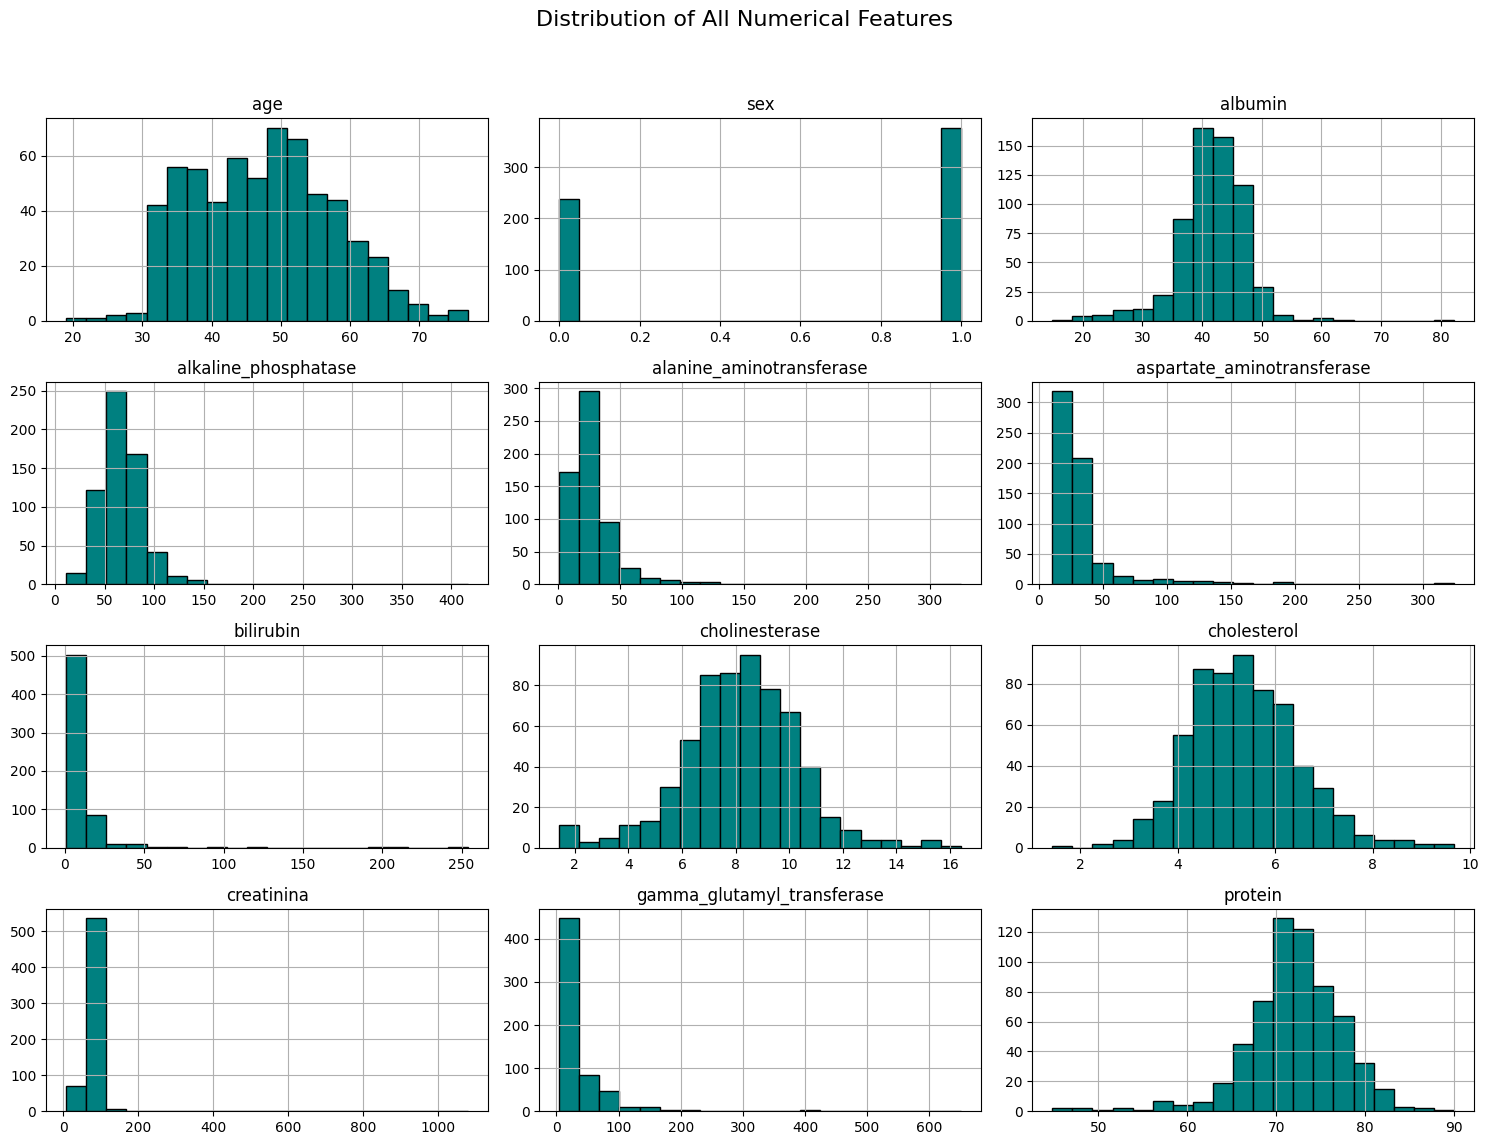

In [446]:
# Plotting histograms for all numerical features to understand overall distributions
df.hist(figsize=(15, 12), bins=20, color='teal', edgecolor='black')
plt.suptitle("Distribution of All Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

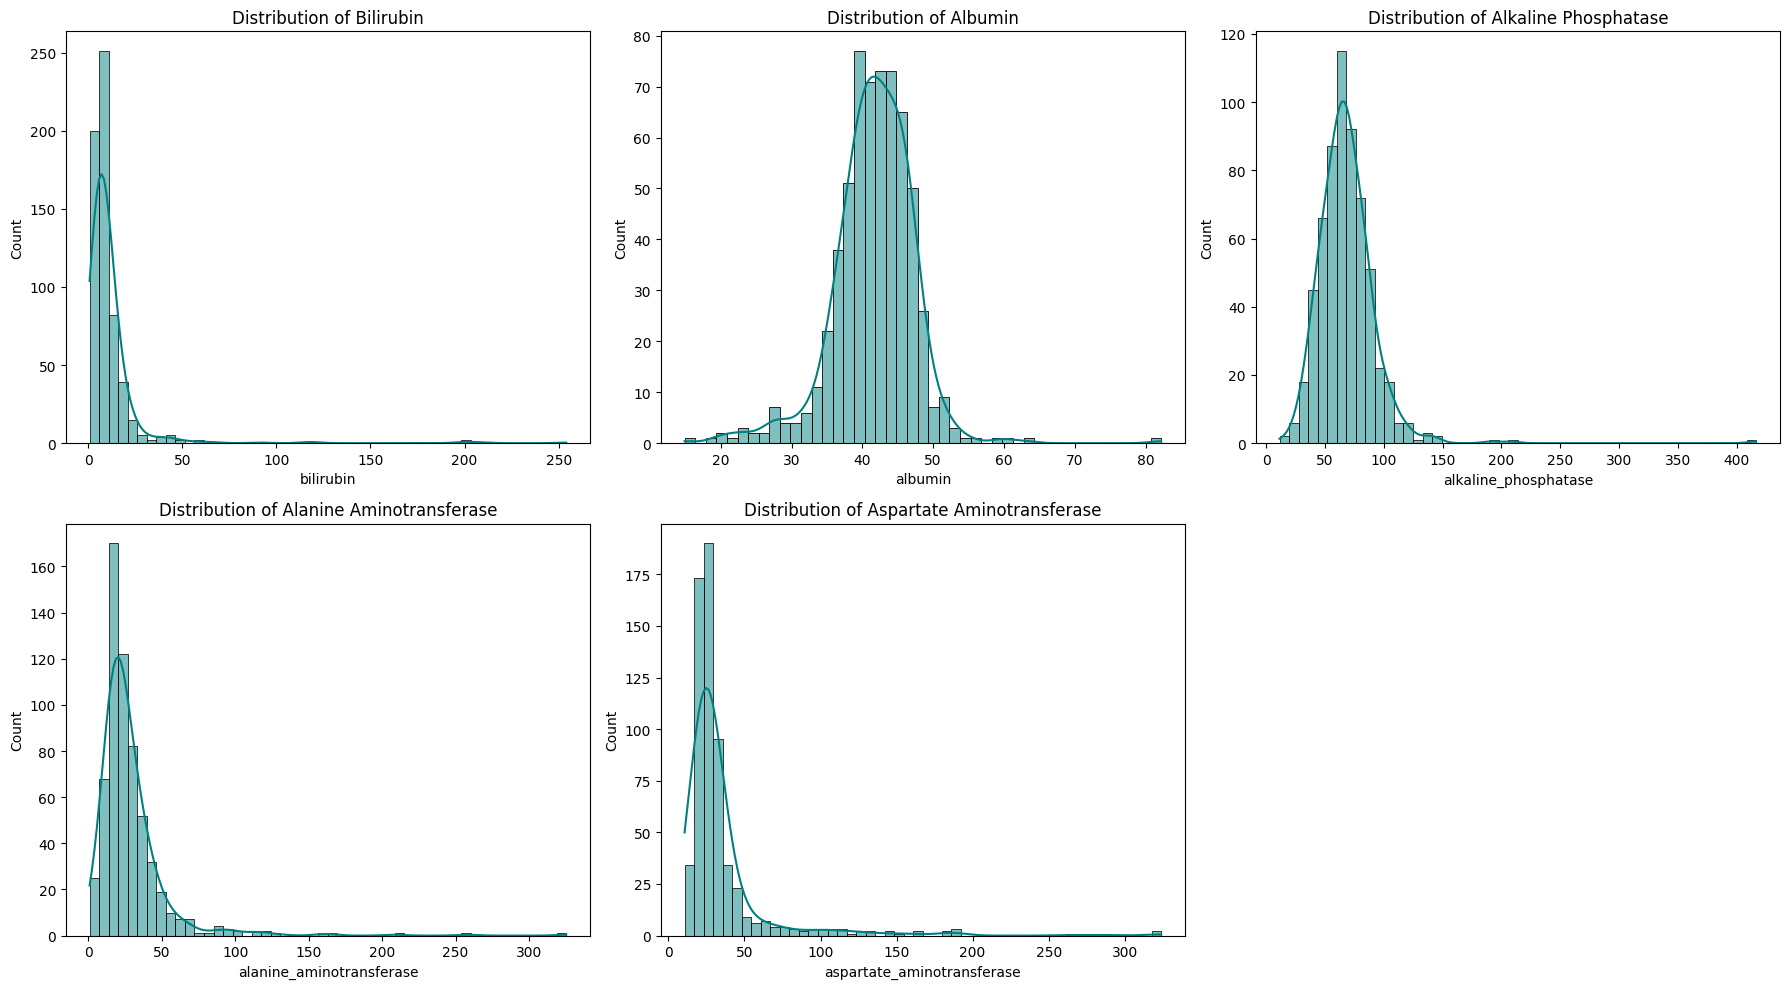

In [447]:
# Visualize the distribution and skewness for the top 5 clinical biomarkers
cols_to_plot = ['bilirubin', 'albumin', 'alkaline_phosphatase', 'alanine_aminotransferase', 'aspartate_aminotransferase']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Distribution of {col.replace('_', ' ').title()}")

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

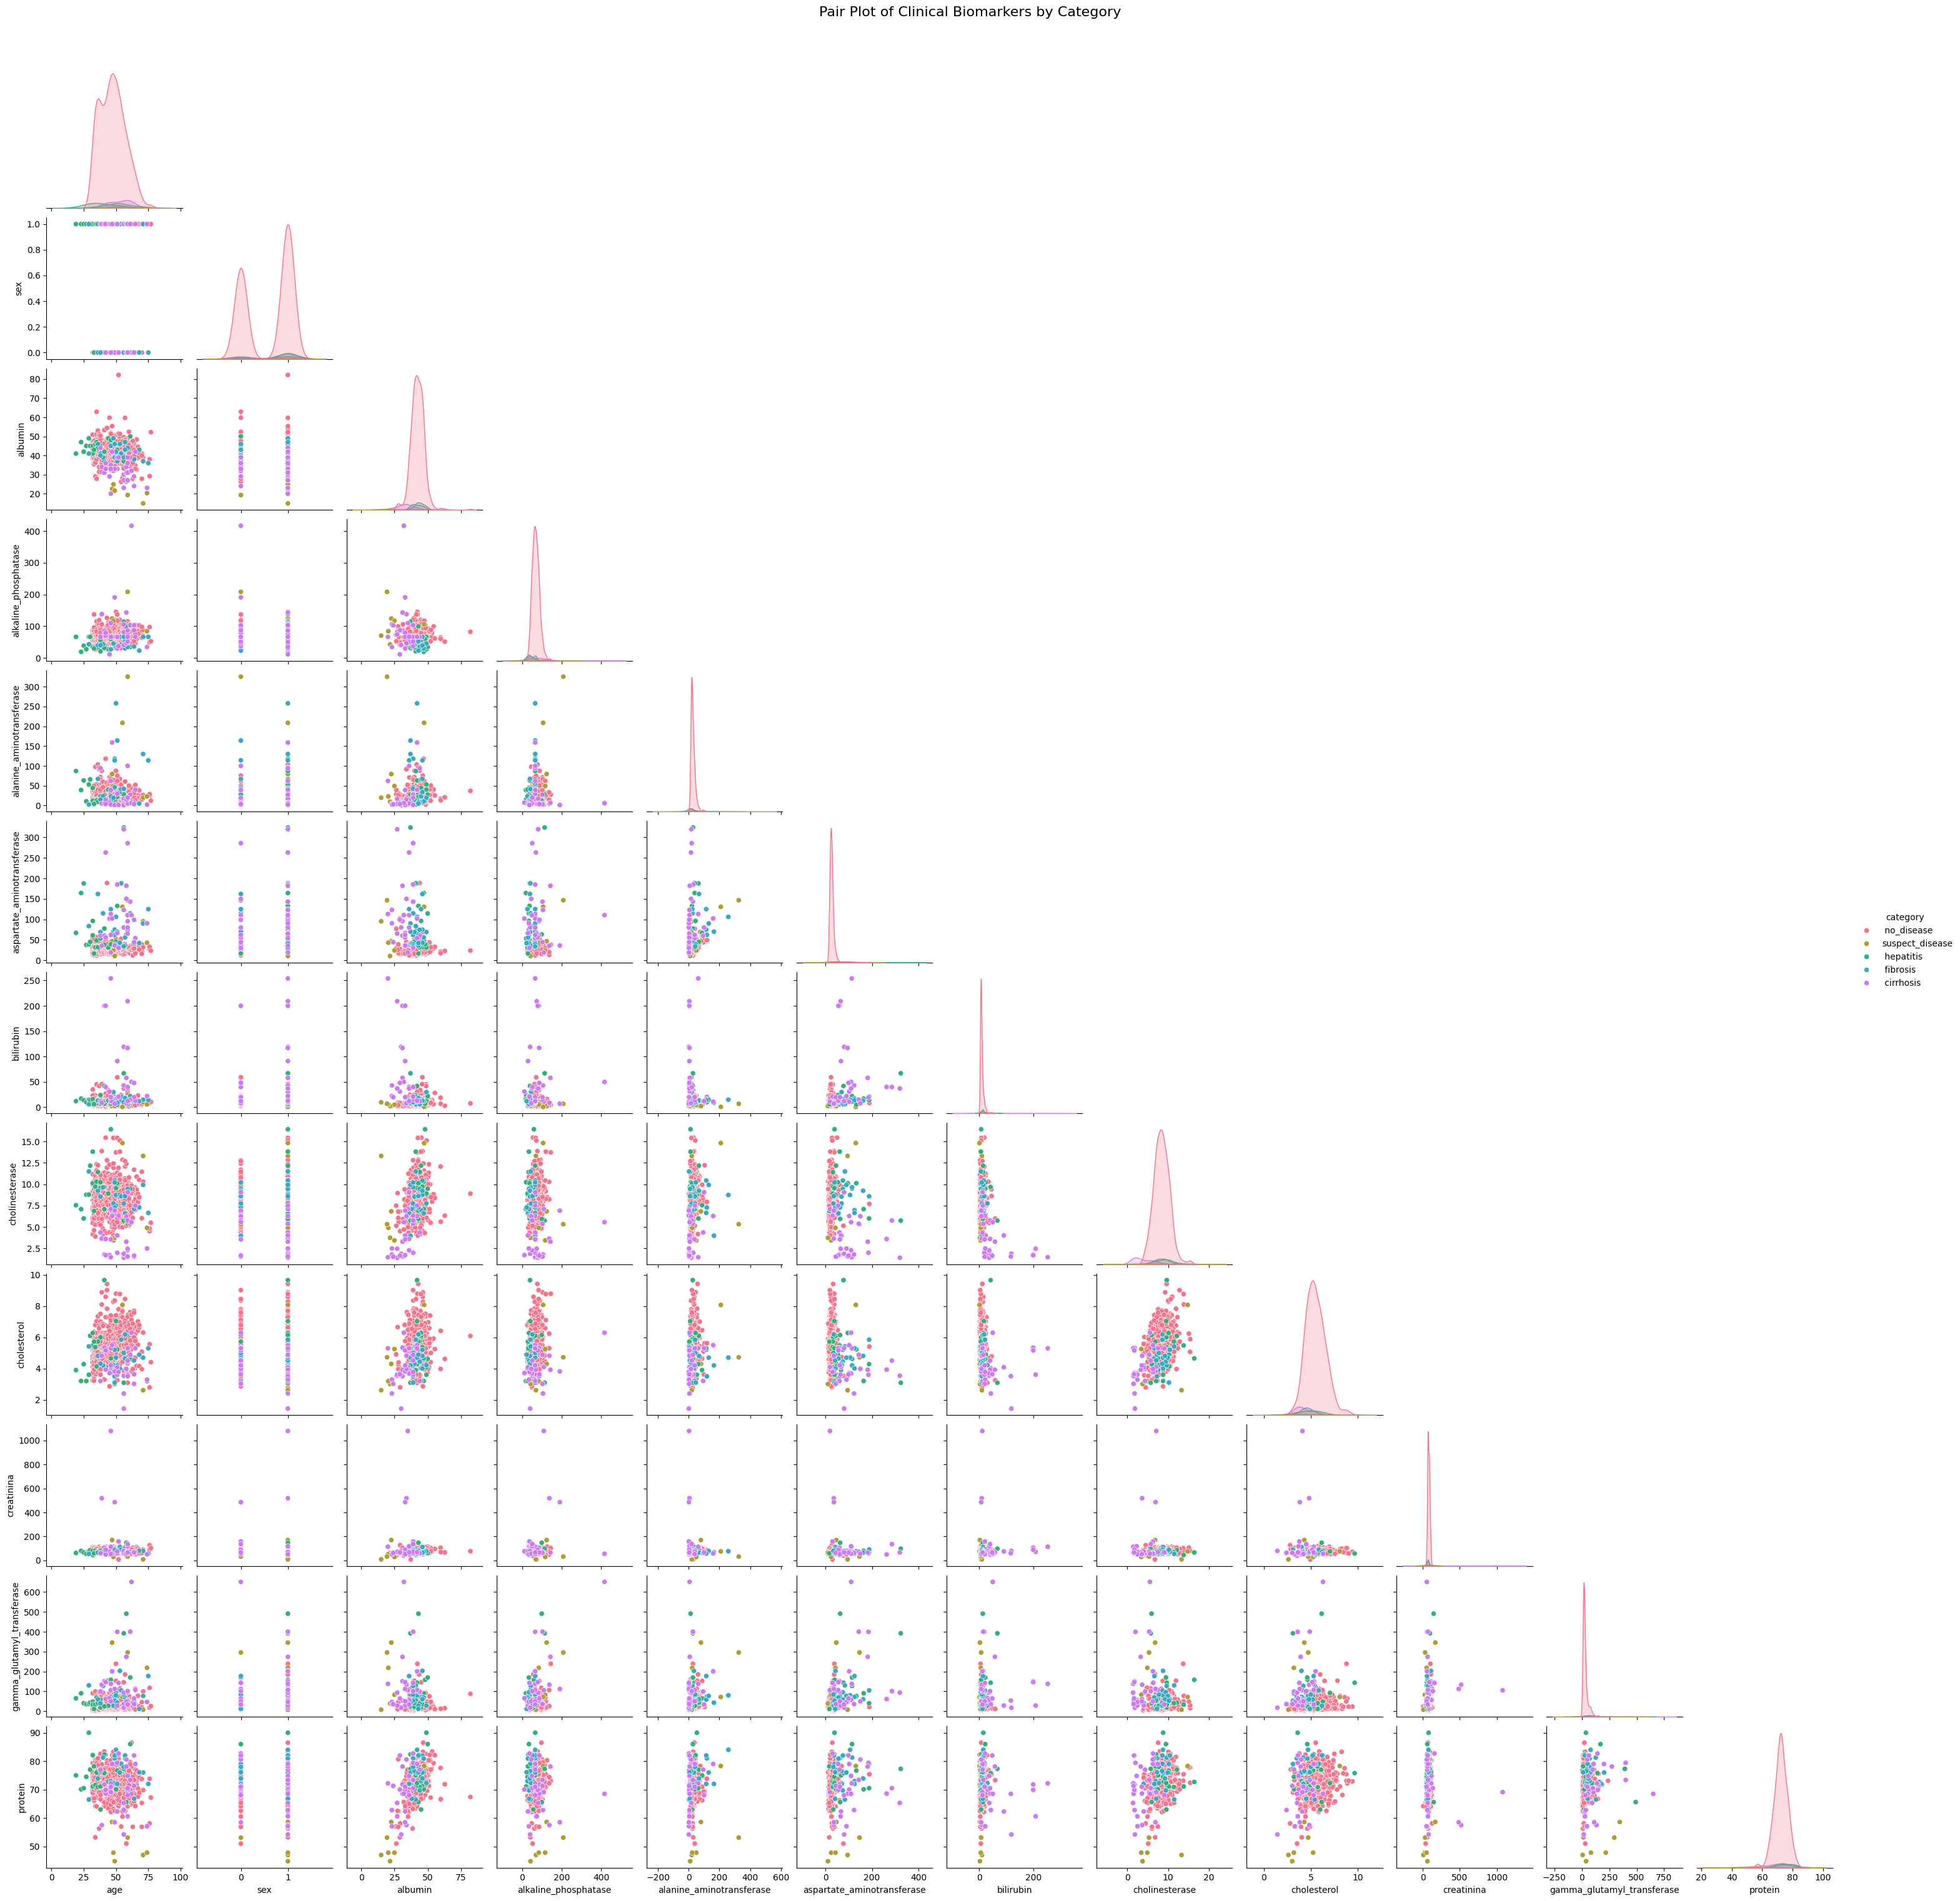

In [448]:
# Pair plot to visualize relationships between all biomarkers, color-coded by diagnosis
# Note: This might take a few moments to render due to the number of features
sns.pairplot(df, hue='category', palette='husl', corner=True)
plt.suptitle("Pair Plot of Clinical Biomarkers by Category", y=1.02, fontsize=16)
plt.show()

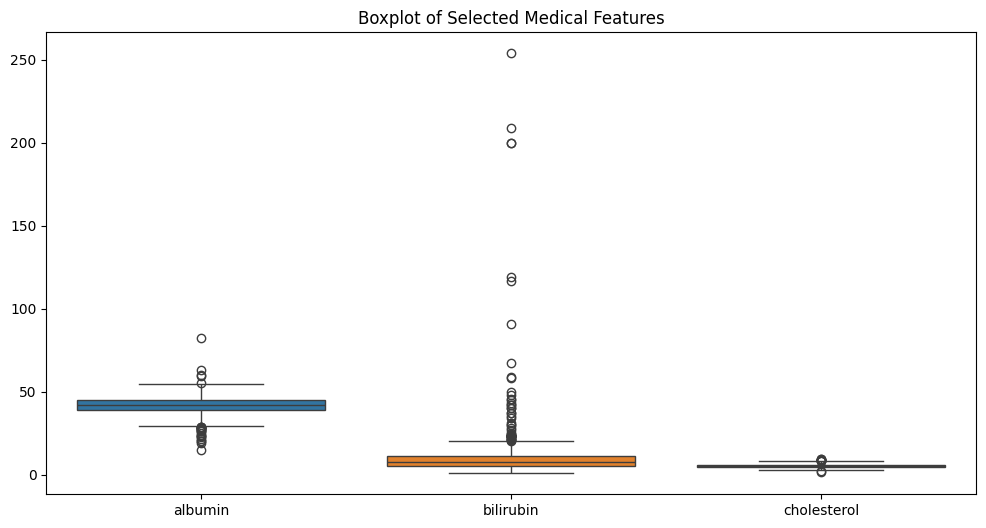

In [449]:
# Visualize outliers using boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['albumin', 'bilirubin', 'cholesterol']])
plt.title("Boxplot of Selected Medical Features")
plt.show()

In [450]:
# Compute correlation matrix
df.corr(numeric_only=True)

,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase,protein
age,1.000000,-0.024544,-0.196842,0.168080,-0.005690,0.088666,0.032492,-0.075093,0.123789,-0.022296,0.153087,-0.153672
sex,-0.024544,1.000000,0.146138,-0.019808,0.161502,0.130891,0.111177,0.169111,-0.029251,0.159589,0.133276,0.051288
albumin,-0.196842,0.146138,1.000000,-0.138015,0.001444,-0.193342,-0.221641,0.375817,0.204731,-0.001594,-0.155440,0.549975
alkaline_phosphatase,0.168080,-0.019808,-0.138015,1.000000,0.166320,0.059637,0.046780,0.033750,0.123197,0.149831,0.440012,-0.055869
alanine_aminotransferase,-0.005690,0.161502,0.001444,0.166320,1.000000,0.273333,-0.038388,0.146729,0.067716,-0.043000,0.248208,0.095016
aspartate_aminotransferase,0.088666,0.130891,-0.193342,0.059637,0.273333,1.000000,0.312231,-0.208536,-0.207938,-0.021387,0.491263,0.039999
bilirubin,0.032492,0.111177,-0.221641,0.046780,-0.038388,0.312231,1.000000,-0.333172,-0.157282,0.031224,0.217024,-0.040729
cholinesterase,-0.075093,0.169111,0.375817,0.033750,0.146729,-0.208536,-0.333172,1.000000,0.420215,-0.011157,-0.110345,0.293041
cholesterol,0.123789,-0.029251,0.204731,0.123197,0.067716,-0.207938,-0.157282,0.420215,1.000000,-0.047437,-0.007185,0.206255
creatinina,-0.022296,0.159589,-0.001594,0.149831,-0.043000,-0.021387,0.031224,-0.011157,-0.047437,1.000000,0.121003,-0.031662


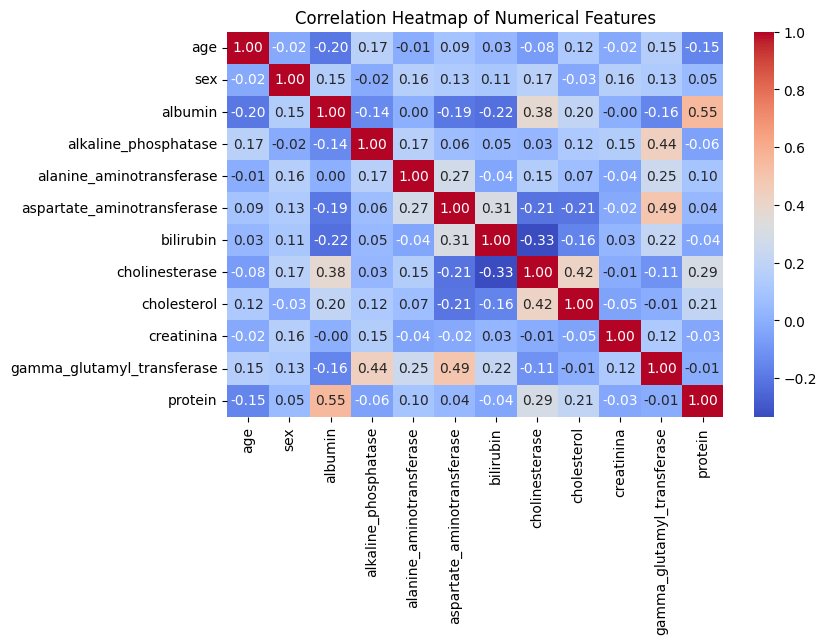

In [451]:
# Visualize correlation using heatmap with numeric correlation values
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,        # Show correlation values
    fmt=".2f"          # Display values with 2 decimal places
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [452]:
df.head()

,category,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase,protein
0,no_disease,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,no_disease,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,no_disease,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,no_disease,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,no_disease,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [453]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   category                    615 non-null    object 
 1   age                         615 non-null    int64  
 2   sex                         615 non-null    int64  
 3   albumin                     615 non-null    float64
 4   alkaline_phosphatase        615 non-null    float64
 5   alanine_aminotransferase    615 non-null    float64
 6   aspartate_aminotransferase  615 non-null    float64
 7   bilirubin                   615 non-null    float64
 8   cholinesterase              615 non-null    float64
 9   cholesterol                 615 non-null    float64
 10  creatinina                  615 non-null    float64
 11  gamma_glutamyl_transferase  615 non-null    float64
 12  protein                     615 non-null    float64
dtypes: float64(10), int64(2), object(1)

####  **Convert target labels into numbers for model training.**


In [454]:
df['category'] = df['category'].str.strip().str.lower()
df['category'].unique()

class_map = {
    'no_disease': 0,
    'cirrhosis': 1,
    'hepatitis': 2,
    'fibrosis': 3,
    'suspect_disease': 4
}

df['target'] = df['category'].map(class_map)
df.drop(columns=['category'], inplace=True)
df['target']

0      0
1      0
2      0
3      0
4      0
      ..
610    1
611    1
612    1
613    1
614    1
Name: target, Length: 615, dtype: int64

#### **“I confirm everything is clean.”**

In [455]:
# Preview final dataset after EDA handling
df.head()

,age,sex,albumin,alkaline_phosphatase,alanine_aminotransferase,aspartate_aminotransferase,bilirubin,cholinesterase,cholesterol,creatinina,gamma_glutamyl_transferase,protein,target
0,32,1,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0
1,32,1,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0
2,32,1,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0
3,32,1,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0
4,32,1,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0


In [456]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         615 non-null    int64  
 1   sex                         615 non-null    int64  
 2   albumin                     615 non-null    float64
 3   alkaline_phosphatase        615 non-null    float64
 4   alanine_aminotransferase    615 non-null    float64
 5   aspartate_aminotransferase  615 non-null    float64
 6   bilirubin                   615 non-null    float64
 7   cholinesterase              615 non-null    float64
 8   cholesterol                 615 non-null    float64
 9   creatinina                  615 non-null    float64
 10  gamma_glutamyl_transferase  615 non-null    float64
 11  protein                     615 non-null    float64
 12  target                      615 non-null    int64  
dtypes: float64(10), int64(3)
memory usa

In [457]:
# Final check for missing values
df.isnull().sum()


age                           0
sex                           0
albumin                       0
alkaline_phosphatase          0
alanine_aminotransferase      0
aspartate_aminotransferase    0
bilirubin                     0
cholinesterase                0
cholesterol                   0
creatinina                    0
gamma_glutamyl_transferase    0
protein                       0
target                        0
dtype: int64

In [458]:
df.isnull().sum()

age                           0
sex                           0
albumin                       0
alkaline_phosphatase          0
alanine_aminotransferase      0
aspartate_aminotransferase    0
bilirubin                     0
cholinesterase                0
cholesterol                   0
creatinina                    0
gamma_glutamyl_transferase    0
protein                       0
target                        0
dtype: int64

##### **Handling Outliers**

In [459]:
# Log-transform skewed medical features to reduce outlier influence
df['bilirubin'] = np.log1p(df['bilirubin'])
df['alkaline_phosphatase'] = np.log1p(df['alkaline_phosphatase'])
df['gamma_glutamyl_transferase'] = np.log1p(df['gamma_glutamyl_transferase'])

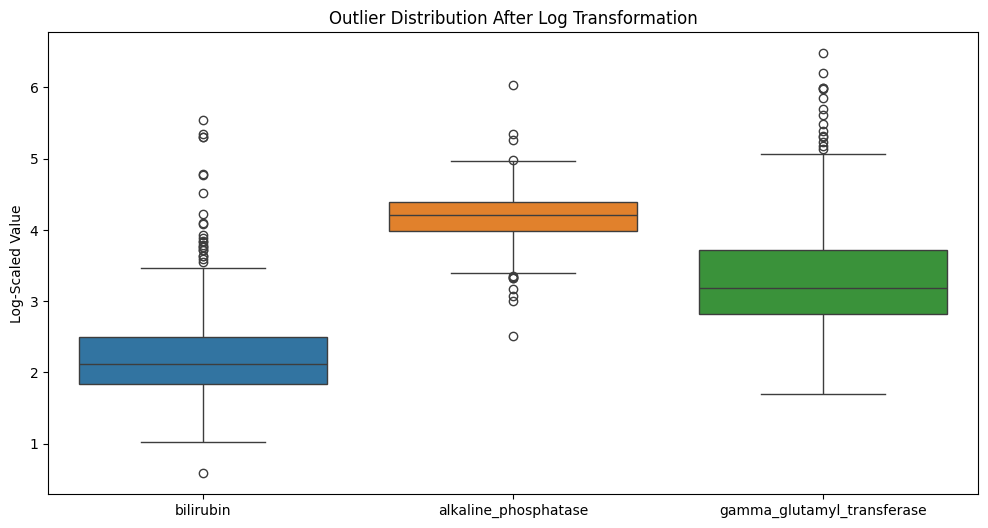

In [460]:
# Visualize outliers AFTER log transformation to see the improvement
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['bilirubin', 'alkaline_phosphatase', 'gamma_glutamyl_transferase']])
plt.title("Outlier Distribution After Log Transformation")
plt.ylabel("Log-Scaled Value")
plt.show()

In [461]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

In [462]:
from sklearn.model_selection import train_test_split

In [463]:
# Following Sir's instruction for a 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,   # 0.3 means 30% for testing
    random_state=42, 
    stratify=y       # Ensures medical categories are balanced in both sets
)

#### **Model Training**

In [464]:
import warnings
import joblib
from sklearn.exceptions import ConvergenceWarning

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Evaluation Tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Hides messy background logs to keep the notebook clean for the presentation
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [465]:
import warnings
warnings.filterwarnings('ignore')

# 1. Define the updated dictionary of models (5 core models)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', verbosity=0)  # Silent mode
}

# 2. Run the benchmarking loop
print("Comparing 5 models using 5-Fold Cross-Validation...")
for name, model in models.items():
    # Cross-validation checks the model on 5 different subsets of data
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: Average Accuracy = {cv_scores.mean():.4f}")

Comparing 5 models using 5-Fold Cross-Validation...
Logistic Regression: Average Accuracy = 0.9209
SVC: Average Accuracy = 0.9047
Decision Tree: Average Accuracy = 0.9070
Random Forest: Average Accuracy = 0.9047
XGBoost: Average Accuracy = 0.9233


In [466]:
# --- Implementing Friend's Suggestion: Robust Scaling & Pipeline (TUNED) ---
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# 1. Define the Tuned Pipeline
# We add hyperparameter tuning to the XGBClassifier for higher accuracy
pipeline_xgb = Pipeline([
    ('scaler', RobustScaler()), 
    ('model', XGBClassifier(
        n_estimators=500,     # Increases the number of trees for deeper learning
        learning_rate=0.05,   # Makes the learning process more precise (slow and steady)
        max_depth=4,          # Limits tree depth to prevent the model from memorizing noise
        eval_metric='mlogloss'
    ))
])

# 2. Train the entire Pipeline
pipeline_xgb.fit(X_train, y_train)

# 3. Predict using the Pipeline
y_pred = pipeline_xgb.predict(X_test)

print("Tuned XGBoost Pipeline with Robust Scaling is now ready!")

Tuned XGBoost Pipeline with Robust Scaling is now ready!


#### **since we got xg-boost as highest accuracy , i choose it**

In [467]:
# Initialize XGBoost classifier for multiclass liver disease prediction
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42
)

In [468]:
# Train the XGBoost model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=5, ...)

In [469]:
# 1. Generate predictions using the test data
y_pred = xgb_model.predict(X_test)

In [470]:
from sklearn.metrics import classification_report, accuracy_score

In [471]:
#Print Accuracy and Classification Report
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
# target_names helps map the 0, 1, 2... back to disease names
print(classification_report(y_test, y_pred, target_names=class_map.keys()))

Overall Accuracy: 0.94

Classification Report:
                 precision    recall  f1-score   support

     no_disease       0.96      1.00      0.98       161
      cirrhosis       0.88      0.78      0.82         9
      hepatitis       0.75      0.43      0.55         7
       fibrosis       0.50      0.33      0.40         6
suspect_disease       1.00      0.50      0.67         2

       accuracy                           0.94       185
      macro avg       0.82      0.61      0.68       185
   weighted avg       0.93      0.94      0.93       185



In [472]:
from sklearn.metrics import confusion_matrix

### **Clinical Performance Interpretation**
To evaluate how this model would perform in a real hospital, we categorize the results into four medical outcomes:

1. **True Positive (TP) / True Negative (TN):** **Correct Diagnosis.** The model accurately identified the patient's stage.
2. **False Positive (FP) - "False Alarm":** The model predicted a disease stage when the patient was actually healthy or at a lower stage. This leads to unnecessary anxiety or extra tests.
3. **False Negative (FN) - "Missed Case":** The model predicted the patient was healthy/lower stage when they were actually sick. **This is the most critical risk, as a patient might not receive treatment.**

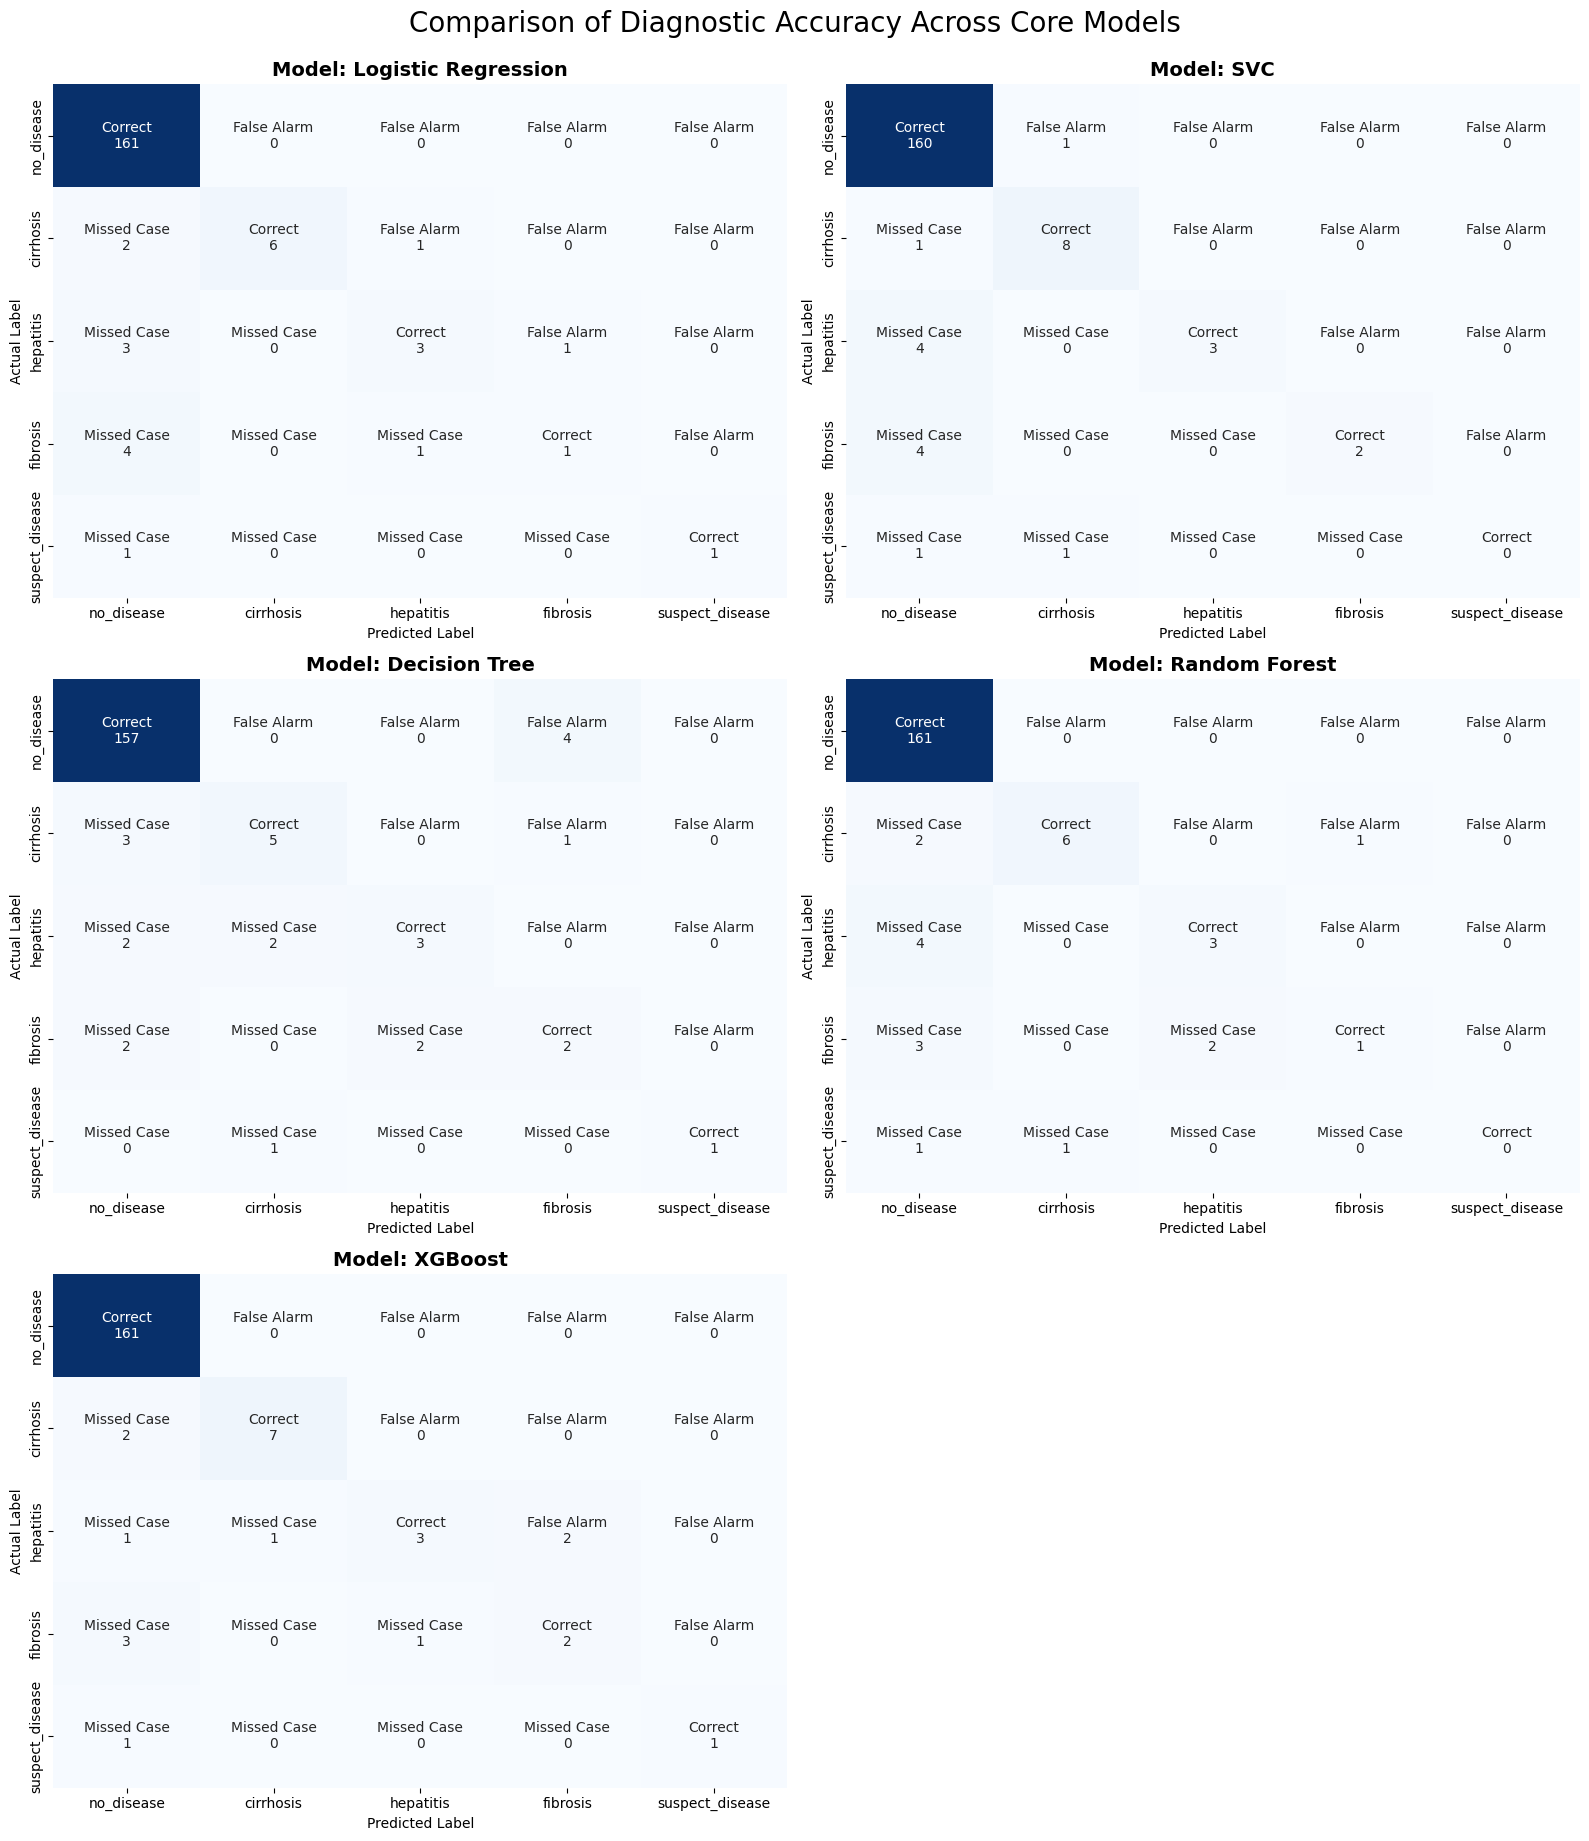

In [473]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Define the updated list of models (5 core models)
all_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', verbosity=0)
}

# 2. Set up a grid for the plots (3 rows, 2 columns for 5 models)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

class_names = list(class_map.keys())

for i, (name, model) in enumerate(all_models.items()):
    # Train model using a pipeline to ensure proper scaling for SVC/LogReg
    clf = make_pipeline(StandardScaler(), model)
    clf.fit(X_train, y_train)
    y_model_pred = clf.predict(X_test)
    
    # Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_model_pred)
    
    # Create custom medical labels for the heatmap
    labels = []
    for row_idx in range(len(cm)):
        row_labels = []
        for col_idx in range(len(cm)):
            count = cm[row_idx, col_idx]
            if row_idx == col_idx:
                label = f"Correct\n{count}"
            elif row_idx < col_idx:
                label = f"False Alarm\n{count}" # Predicted disease when healthy/lower stage
            else:
                label = f"Missed Case\n{count}" # Predicted healthy when disease present
            row_labels.append(label)
        labels.append(row_labels)

    # Plot on the specific subplot
    sns.heatmap(cm, annot=np.array(labels), fmt="", cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, 
                ax=axes[i], cbar=False)
    
    axes[i].set_title(f'Model: {name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')

# Hide the 6th (empty) subplot since we only have 5 models
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Comparison of Diagnostic Accuracy Across Core Models', fontsize=20, y=1.02)
plt.show()

##### **5-Fold Cross-Validation**

In [474]:
#To verify model stability and consistent accuracy across different data splits
from sklearn.model_selection import cross_val_score

In [475]:
# 4. Model Robustness Check: 5-Fold Cross-Validation
# We use X and y (the full dataset) to see how the model generalizes
scores = cross_val_score(xgb_model, X, y, cv=5)

print(f"Cross-validated Accuracy Scores: {scores}")
print(f"Average Accuracy: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Cross-validated Accuracy Scores: [0.92682927 0.94308943 0.96747967 0.91056911 0.91056911]
Average Accuracy: 0.93 (+/- 0.04)


##### **Since the Cross-Validation score (93%) and Test accuracy (95%) are nearly identical, the model is generalized and not overfitting(memorizing).**

Generating ROC Curves for core models...
Finished: Logistic Regression
Finished: SVC
Finished: Decision Tree
Finished: Random Forest
Finished: XGBoost


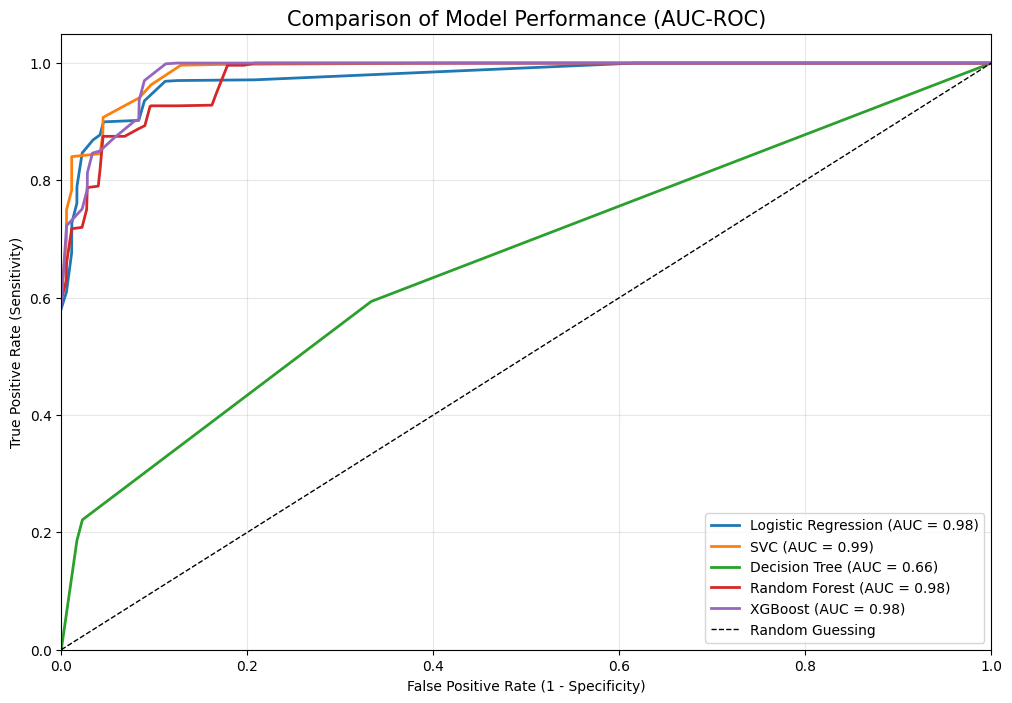

In [476]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import numpy as np

# 1. Binarize the labels for multi-class ROC
unique_classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=unique_classes)
n_classes = y_test_bin.shape[1]

# 2. Updated core models (5 models)
all_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', verbosity=0)
}

plt.figure(figsize=(12, 8))

print("Generating ROC Curves for core models...")

for name, model in all_models.items():
    # Pipeline ensures that distance-based models (SVC/Logistic) are scaled
    clf = make_pipeline(StandardScaler(), model)
    clf.fit(X_train, y_train)
    
    # Get predicted probabilities
    y_score = clf.predict_proba(X_test)
    
    # Compute Macro-average ROC curve
    all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_score[:, i])[0] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    
    # Plot the curve
    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_auc:0.2f})', lw=2)
    print(f"Finished: {name}")

# Plot styling
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Comparison of Model Performance (AUC-ROC)', fontsize=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

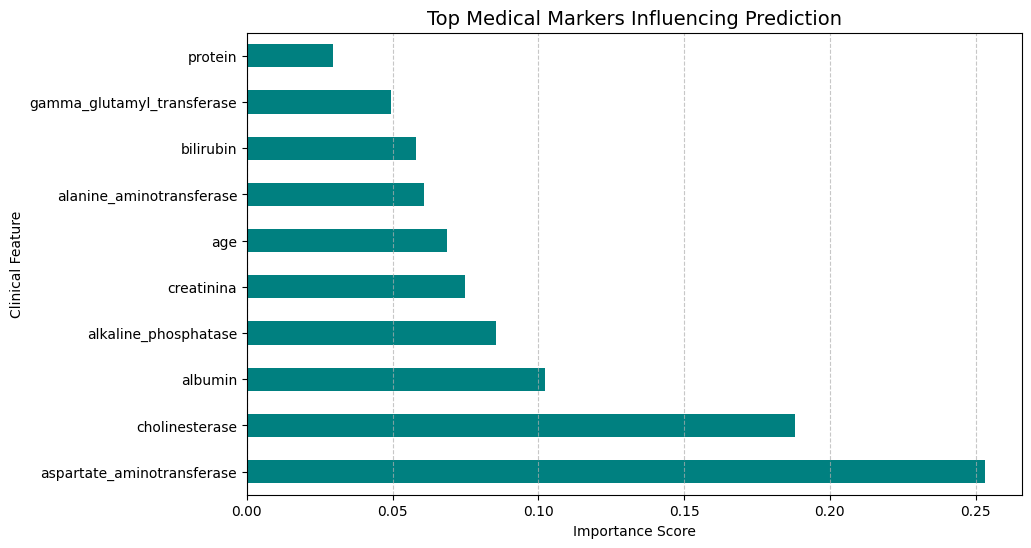

In [477]:
# 4. Plot Feature Importance to identify top medical markers
plt.figure(figsize=(10, 6))

# Extract importance from the trained XGBoost model
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)

# Plotting the top 10 most influential features
feat_importances.nlargest(10).plot(kind='barh', color='teal')

plt.title('Top Medical Markers Influencing Prediction', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Clinical Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [478]:
# We save the pipeline instead of just the model to ensure consistency on the website
joblib.dump(pipeline_xgb, 'liver_disease_pipeline.pkl')
joblib.dump(class_map, 'class_mapping.pkl')

print("Deployment files saved: Pipeline and Class Map.")

Deployment files saved: Pipeline and Class Map.


#### **DEPLOYMENT**

In [479]:
import joblib

# 1. Save the best pipeline (contains both the Scaler and the XGBoost model)
joblib.dump(pipeline_xgb, 'liver_disease_pipeline.pkl')

# 2. Save the category mapping (e.g., 0: 'Blood Donor', 1: 'Hepatitis')
joblib.dump(class_map, 'class_mapping.pkl')

print("Files saved successfully!")

Files saved successfully!
